# Analisi esperimenti numerici

Un piccolo notebook per analizzare i dati degli esperimenti numerici, che salvo in un file `.csv`

## Imports, creazione del dataframe

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from decimal import Decimal

from utilities import *
import optperfprofpy    

In [7]:
CSV_FILENAME = "bench-v0.1.4alpha-25_05-mpmath_ref.csv"

In [8]:
df = pd.read_csv(CSV_FILENAME)

In [9]:
df.shape

(2618, 26)

In [11]:
df.head()

,kind,n,eltype,ishermitian,approximant,algorithm,schur_time,alpha_time,eval_bound_time,eval_pade_time,...,cond_q,epsilon,rel_err_F,abs_err_1,nrm1_Ytrue,Ytrue_method,cond_expA_F,condA_1,condA_2,precision
0,rand,8,Float64,False,scaling_and_squaring,NaN,NaN,NaN,NaN,NaN,...,NaN,2.220446e-16,2.373560e-16,1.802861592277032e-14,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,53
1,rand,8,Float64,False,diagonalcheap,transfree,0.000000,0.000108,2.770559,0.859236,...,23.980249,2.220446e-16,8.831571e-16,7.031690783208075e-14,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,53
2,rand,8,Float64,False,diagonalcheap,transfree,0.000000,0.000489,0.022919,0.001683,...,22.670589,1.727234e-77,2.966314e-77,2.17128735881013e-75,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,256
3,rand,8,Float64,False,diagonalcheap,transfree,0.000000,0.001384,0.018613,0.004801,...,22.275739,1.331998e-256,3.663965e-256,2.73813523479176e-254,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,851
4,rand,8,Float64,False,diagonalcheap,complexschur,0.006261,0.000244,3.183234,0.867517,...,13.821267,2.220446e-16,1.374308e-15,1.278113663697772e-13,80.90624298686493,mpmath_1792,4.871499,416.710942,183.633838,53


## Descrizione (e aggiustamento) colonne

In [12]:
df.columns

Index(['kind', 'n', 'eltype', 'ishermitian', 'approximant', 'algorithm',
       'schur_time', 'alpha_time', 'eval_bound_time', 'eval_pade_time',
       'squaring_time', 'total_time', 'm', 's', 'delta', 'psi', 'cond_q',
       'epsilon', 'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'Ytrue_method',
       'cond_expA_F', 'condA_1', 'condA_2', 'precision'],
      dtype='object')

Ecco una descrizione delle colonne:
- `kind`: un identificativo del "tipo" di matrice che ha prodotto i risultati della riga corrispondente
- `n`: dimensione della matrice 
- `eltype`: tipo degli elementi della matrice
- `ishermitian`: se la matrice è Hermitiana o meno 
- `approximant`: approssimante scelta per il calcolo dell'esponenziale di matrice 
- `algorithm`: algoritmo usato da `exp_mp`. Può essere Schur reale, Schur complesso o niente Schur
- `schur_time`: tempo impiegato per calcolare la forma di Schur
- `alpha_time`: tempo totale impiegato per valutare l'$\alpha_{\min}$ in `exp_mp`
- `eval_bound_time`: tempo totale impiegato per valutare il bound sull'errore in `exp_mp`. Si osservi che la valutazione del bound può formare nuove potenze di $A$
- `eval_pade_time`: tempo totale impiegato nel valutare l'approssimante 
- `squaring_time`: tempo speso nella fase di squaring
- `total_time`: tempo totale impiegato dall'algoritmo (viene misurato direttamente. Non è la somma dei tempi precedenti)
- `m`: grado dell'approssimante scelto dall'algoritmo `exp_mp`
- `s`: fattore di scaling scelto dall'algoritmo `exp_mp` ($A$ viene scalata di $2^{-s}$)
- `delta`: valore finale di $\delta$ (ossia upper bound sull'errore) prodotto in `exp_mp`
- `psi`: valore finale di $\psi$ (ossia, stima di $\exp(A)$ usata stimare per l'errore relativo durante l'esecuzione di `exp_mp`)
- `cond_q`: valore finale del numero di condizionamento (in norma 1) di $q_m(2^{-s}A)$
- `epsilon`: valore $\epsilon$ usato per la tolleranza sull'errore relativo. Può essere passato in input, il valore di default è la precisione di macchina della precisione usata all'interno dell'algoritmo
- `rel_err_F`: accuratezza relativa della soluzione calcolata, in norma di Frobenius
- `abs_err_1`: errore assoluto della soluzione calcolata, in norma 1
- `nrm1_Ytrue`: norma 1 della soluzione di riferimento $Y_{\textup{true}}$ (considerata esatta nella valutazione dell'errore relativo)
- `Ytrue_method`: metodo usato per costruire $Y_{\textup{true}}$. La soluzione esatta può essere stata fornita insieme all'input $A$, o altrimenti può essere stata costruita per diagonalizzazione o eseguendo `exp_mp` in precisione più alta
- `cond_expA_F`: $\kappa_{\exp}(A)$, numero di condizionamento dell'esponenziale di $A$, in norma di Frobenius (se $A$ è troppo grande, il valore è `NaN`. Infatti il calcolo è "esatto")
- `condA_1`: $\kappa_1(A)$, numero di condizionamento di $A$ in norma 1
- `condA_2`: $\kappa_2(A)$, numero di condizionamento di $A$ in norma 2
- `precision`: il valore di precisione usato all'interno dell'algoritmo. Esso determina il valore della precisione di macchina $u$

In [13]:
df.dtypes

kind                object
n                    int64
eltype              object
ishermitian           bool
approximant         object
algorithm           object
schur_time         float64
alpha_time         float64
eval_bound_time    float64
eval_pade_time     float64
squaring_time      float64
total_time         float64
m                  float64
s                  float64
delta              float64
psi                float64
cond_q             float64
epsilon            float64
rel_err_F          float64
abs_err_1           object
nrm1_Ytrue          object
Ytrue_method        object
cond_expA_F        float64
condA_1            float64
condA_2            float64
precision            int64
dtype: object

In [14]:
for colname in ["abs_err_1", "nrm1_Ytrue"]:
    if df[colname].dropna().map(type).eq(str).all():
        df[colname] = df[colname].map(Decimal)

## Analisi

In [15]:
df.columns

Index(['kind', 'n', 'eltype', 'ishermitian', 'approximant', 'algorithm',
       'schur_time', 'alpha_time', 'eval_bound_time', 'eval_pade_time',
       'squaring_time', 'total_time', 'm', 's', 'delta', 'psi', 'cond_q',
       'epsilon', 'rel_err_F', 'abs_err_1', 'nrm1_Ytrue', 'Ytrue_method',
       'cond_expA_F', 'condA_1', 'condA_2', 'precision'],
      dtype='object')

### Com'è stata ottenuta $Y_{\textup{true}}$?

In [16]:
ytrue_counts = df['Ytrue_method'].value_counts()
ytrue_percentages = (100 * ytrue_counts / df.shape[0]).round(2)

result = pd.DataFrame({
    'Count': ytrue_counts,
    'Percentage': ytrue_percentages
})

result

,Count,Percentage
Ytrue_method,,
mpmath_1792,2485,94.92
given,133,5.08


### $\delta$ è un upper bound?

Prima di tutto, concentriamoci su dove $\delta$ c'è. Ovvero, guardiamo a dove l'algoritmo è `exp_mp` e non lo scaling e squaring.

In [17]:
print(f"There are {sum(df["delta"].isna())} samples with delta = NaN ({100 * sum(df["delta"].isna() / df.shape[0]):2.2f}% of the total)")
print(f"There are {sum(df["delta"]==0)} samples with delta = 0   ({100 * sum(df["delta"]==0) / df.shape[0]:2.2f}% of the total)")


There are 486 samples with delta = NaN (18.56% of the total)
There are 306 samples with delta = 0   (11.69% of the total)


I $\delta = \mathtt{NaN}$ possono anche essere dovuti al fatto che $A$ è Hermitiana. In questo caso infatti l'algoritmo diagonalizza, e i parametri $m,s,\psi,\delta,\kappa_A$ sono `NaN`.

Per fare l'analisi su $\delta$, queste righe le togliamo. Inoltre, teniamo traccia di dove $\delta$ è uguale a $0$.

In [18]:
delta_present   = df["delta"].dropna().index  # togliamo le righe dove delta è NaN
delta_is_0_idxs = df[df["delta"]==0].index

df_delta = df.loc[delta_present]
df_delta.shape

(2132, 26)

La formula (3.14) di [hf19_mpexpm] legge:
$$
    \lvert\lvert\exp(X) - r_m(X)\rvert\rvert \le \lvert\lvert q_m(X)^{-1}\rvert\rvert\,\left\vert q_m(\alpha_d(X)e^{\alpha_d(X)}-p_m(\alpha_d(X))\right\vert\coloneqq\delta
$$


La domanda più pressante che mi viene in mente è: ma alla fine, $\delta$ è un upper bound all'errore, come rivendicano gli autori dell'articolo? 

***OSS***: Consideriamo che per il calcolo di un termine di $\delta$ si usa una stima della norma 1 eh...

In [19]:
delta_is_upper_bound_to_abserr = df_delta["abs_err_1"] <= df_delta["delta"]
d_is_ub_to_abserr_and_d_ne0 = df_delta.loc[~df_delta.index.isin(delta_is_0_idxs), "abs_err_1"] \
                                <= df_delta.loc[~df_delta.index.isin(delta_is_0_idxs), "delta"]

print(f"abs_err <= delta in {sum(delta_is_upper_bound_to_abserr)} out of {df_delta.shape[0]} samples")
print(f"Excluding those for which delta = 0, abs_err <= delta in {sum(d_is_ub_to_abserr_and_d_ne0)} out of {df_delta[~df_delta.index.isin(delta_is_0_idxs)].shape[0]} samples")
print(f"abs_err = delta = 0 in {df_delta[df_delta.index.isin(delta_is_0_idxs) & (df_delta["abs_err_1"] == 0)].shape[0]} samples")

abs_err <= delta in 83 out of 2132 samples
Excluding those for which delta = 0, abs_err <= delta in 32 out of 1826 samples
abs_err = delta = 0 in 51 samples


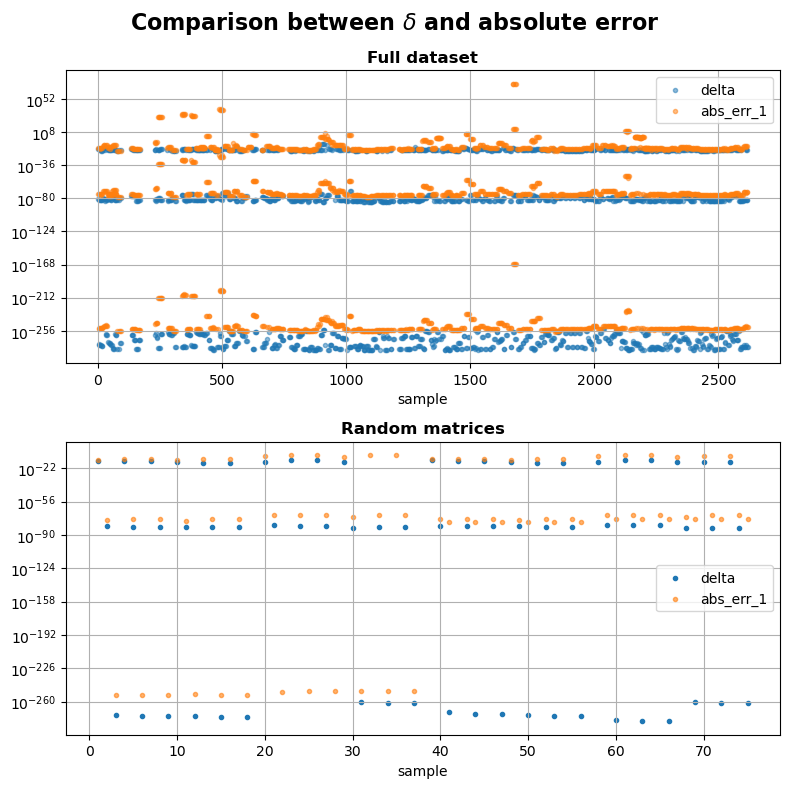

In [20]:
fig, axs = plt.subplots(2,1, figsize=(8,8))
fig.suptitle(r"Comparison between $\delta$ and absolute error", fontsize=16, fontweight="bold")

axs[0].scatter(df_delta["delta"].index, df_delta["delta"],
                marker='.', alpha=0.5, label="delta")
axs[0].scatter(df_delta["abs_err_1"].index, df_delta["abs_err_1"],
               marker='.', alpha=0.5, label="abs_err_1")
axs[0].set_title("Full dataset", fontweight="bold")


#subplot 2: solo matrici rand
df_delta_rand = df_delta[df_delta["kind"].isin(["rand","rand_big"])]

axs[1].scatter(df_delta_rand["delta"].index, df_delta_rand["delta"],
                marker='.', label="delta")
axs[1].scatter(df_delta_rand["abs_err_1"].index, df_delta_rand["abs_err_1"],
               marker='.', alpha=0.6, label="abs_err_1")
axs[1].set_title("Random matrices", fontweight="bold")

for ax in axs:
    ax.set_yscale('log')
    ax.set_xlabel('sample')
    #ax.set_ylabel('abs_err_1 / delta')
    ax.set_yscale('log')
    ax.legend()
    ax.grid("True")

plt.tight_layout()
plt.show()

Allora, vista così la situazione non è brutta ma non così malvagia...

Però per quasi tutti gli esempi l'errore assoluto è maggiore di $\delta$... E questo è male.

Confrontiamo il rapporto tra `abs_err_1` e `nrm1_Ytrue` (ossia l'errore relativo) con  $\delta$.

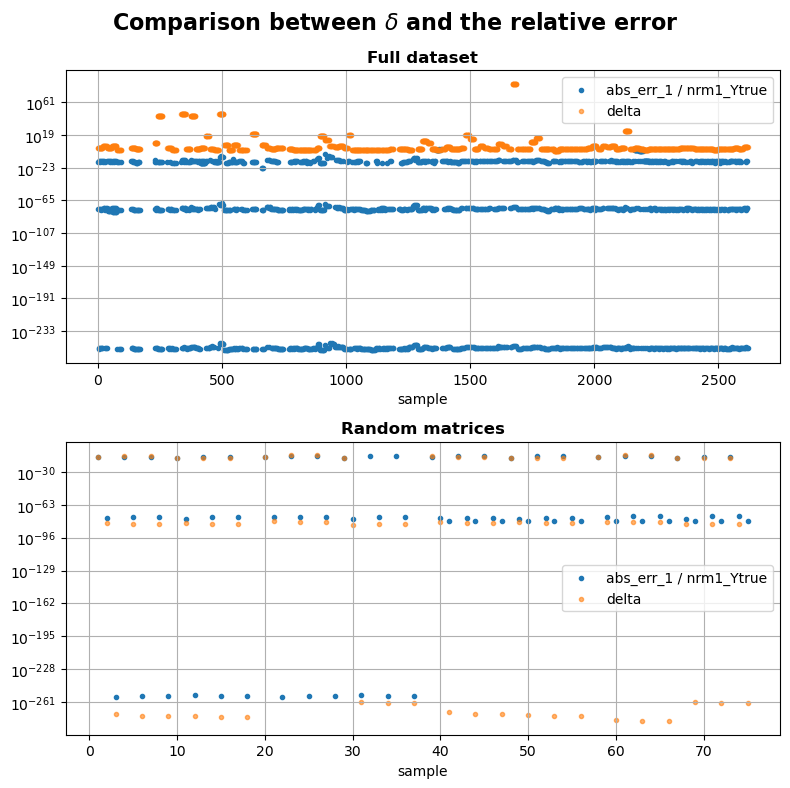

In [25]:
fig, axs = plt.subplots(2,1, figsize=(8,8))
fig.suptitle(r"Comparison between $\delta$ and the relative error", fontsize=16, fontweight="bold")

# subplot 1: tutte le matrici
# escludiamo i samples con delta == 0, perché la divisione dà problemi
df_delta_delne0 = df_delta[~df_delta.index.isin(delta_is_0_idxs)]

y  = df_delta_delne0["abs_err_1"] / df_delta_delne0["nrm1_Ytrue"]
y2 = df_delta_delne0["nrm1_Ytrue"].map(Decimal)

axs[0].scatter(y.index, y, marker='.', label="abs_err_1 / nrm1_Ytrue")
axs[0].scatter(y2.index, y2, marker='.', alpha=0.6, label="delta")
axs[0].set_title("Full dataset", fontweight="bold")

#subplot 2: solo matrici rand
df_delta_rand = df_delta[df_delta["kind"].isin(["rand","rand_big"])]

y_rand  = df_delta_rand["abs_err_1"] / df_delta_rand["nrm1_Ytrue"]
y2_rand = df_delta_rand["delta"]

axs[1].scatter(y_rand.index, y_rand, marker='.', label="abs_err_1 / nrm1_Ytrue")
axs[1].scatter(y2_rand.index, y2_rand, marker='.', alpha=0.6, label="delta")
axs[1].set_title("Random matrices", fontweight="bold")

for ax in axs:
    ax.set_yscale('log')
    ax.set_xlabel('sample')
    #ax.set_ylabel('abs_err_1 / delta')
    ax.set_yscale('log')
    ax.legend()
    ax.grid("True")

plt.tight_layout()
plt.show()

In effetti il criterio di arresto dell'algoritmo è 
$$
    \delta < u * \psi
$$
dove $\psi=r_m(2^{-s}A)\approx\exp(2^{-s}A)$. Almeno questo è rispettato?

In [26]:
stop_criterion_satisfied = df_delta["delta"].dropna()/df_delta["psi"] < df_delta["precision"]

print(f"The stopping criterion is satisfied in {sum(stop_criterion_satisfied)} is out of {df_delta.shape[0]} samples")

The stopping criterion is satisfied in 2132 is out of 2132 samples


Buone notizie. Era scontata come cosa, però.

Ok. $\delta$ non è in generale un upper bound all'errore assoluto. Ci chiediamo però se ci sono casi in cui $\delta$ non limita l'errore assoluto, ma vale $\mathtt{err\_rel}\le\delta/\psi$. 

**DA QUI, RIVEDERE**

In [80]:
psi_le_nrm1Ytrue = df_delta["psi"].map(Decimal) <= df_delta["nrm1_Ytrue"].map(Decimal)

print(f"psi <= delta in {sum(psi_le_nrm1Ytrue)} out of {df_delta.shape[0]} samples")

psi <= delta in 1694 out of 2132 samples


In [81]:
relerr_is_le_delta = (df_delta["abs_err_1"]/df_delta["nrm1_Ytrue"]) <= df_delta["delta"]
print(f"rel_err <= delta in {sum(relerr_is_le_delta)} out of {df_delta.shape[0]} samples")

relerr_is_le_delta_over_psi = (df_delta["abs_err_1"]/df_delta["nrm1_Ytrue"]) <= df_delta["delta"]/df_delta["psi"]
print(f"rel_err <= delta/psi in {sum(relerr_is_le_delta_over_psi)} out of {df_delta.shape[0]} samples")

rel_err <= delta in 245 out of 2132 samples
rel_err <= delta/psi in 70 out of 2132 samples


In [104]:
df_delta[(df_delta["abs_err_1"]/df_delta["nrm1_Ytrue"]) > df_delta["delta"]][["kind", "approximant", "algorithm", "abs_err_1", "nrm1_Ytrue", "delta", "epsilon"]]

,kind,approximant,algorithm,abs_err_1,nrm1_Ytrue,delta,epsilon
2,rand,diagonalcheap,transfree,2.17128735881013E-75,80.90624298686493,5.056417e-82,1.727234e-77
3,rand,diagonalcheap,transfree,2.73813523479176E-254,80.90624298686493,5.499168e-274,1.331998e-256
5,rand,diagonalcheap,complexschur,1.96922028607046E-74,80.90624298686493,1.011529e-82,1.727234e-77
6,rand,diagonalcheap,complexschur,1.069963859292434E-253,80.90624298686493,1.597230e-275,1.331998e-256
8,rand,diagonalcheap,realschur,2.166124929126614E-74,80.90624298686493,1.011529e-82,1.727234e-77
...,...,...,...,...,...,...,...
2613,neumann_16,taylor,complexschur,4.409780854466629E-72,5168.379063993997,8.236092e-83,1.727234e-77
2614,neumann_16,taylor,complexschur,3.151321771339151E-251,5168.379063993997,7.953642e-278,1.331998e-256
2615,neumann_16,taylor,realschur,2.159636872579942E-11,5168.379063993997,6.661338e-16,2.220446e-16
2616,neumann_16,taylor,realschur,4.409780854466629E-72,5168.379063993997,8.236092e-83,1.727234e-77


In [105]:
pd.concat(
    [
        df_delta["delta"],
        (df_delta["abs_err_1"] / df_delta["nrm1_Ytrue"]).rename("rel_err_1"),
        df_delta["abs_err_1"]
    ],
    axis=1,
)

,delta,rel_err_1,abs_err_1
1,1.805282e-15,8.691159697465701021457525911E-16,7.031690783208075E-14
2,5.056417e-82,2.683708053484373179237614403E-77,2.17128735881013E-75
3,5.499168e-274,3.384331213150379846310687790E-256,2.73813523479176E-254
4,3.846375e-15,1.579746650583284195234191986E-15,1.278113663697772E-13
5,1.011529e-82,2.433953442122088759442390427E-76,1.96922028607046E-74
...,...,...,...
2613,8.236092e-83,8.532231865862520835389478838E-76,4.409780854466629E-72
2614,7.953642e-278,6.097311618052810872860383335E-255,3.151321771339151E-251
2615,6.661338e-16,4.178557427463587427038045891E-15,2.159636872579942E-11
2616,8.236092e-83,8.532231865862520835389478838E-76,4.409780854466629E-72


In [ ]:
df_delta[["abs_err_1", "nrm1_Ytrue", "delta"]]

### Errore ottenuto

Vediamo se il classico bound 
$$
    \frac{\hat{Y}-Y}{Y} \lesssim O(u)\cdot\kappa_{exp}(A)
$$
è rispettato.

In [82]:
print("Is `cond_expA_F` a NaN value?")
display(df["cond_expA_F"].isna().value_counts())

print(f"The matrices for which `cond_expA_F` is NaN are: {', '.join(df[df["cond_expA_F"].isna()]["kind"].unique())}")

print("This is `ChainRule.rrule(exp, A)`'s fault (I checked)")

Is `cond_expA_F` a NaN value?


cond_expA_F
False    2542
True       76
Name: count, dtype: int64

The matrices for which `cond_expA_F` is NaN are: Fasi_6, Fasi_7, Fasi_11, dorr_10_100.0
This is `ChainRule.rrule(exp, A)`'s fault (I checked)


In [89]:
def relerr_satisfies_bound_within_factor(df, k=0):
    return df.apply(lambda r: r["rel_err_F"] <= (r["n"]**k) * r["epsilon"] * r["cond_expA_F"], axis=1)

print(f"Out of {df.shape[0]} samples:")
print(f"\t{sum(relerr_satisfies_bound_within_factor(df, 0))} are such that the relative error is bounded by u * k")
print(f"\t{sum(relerr_satisfies_bound_within_factor(df, 1))} are such that the relative error is bounded by n * u * k")
print(f"\t{sum(relerr_satisfies_bound_within_factor(df, 2))} are such that the relative error is bounded by n^2 * u * k")

print("where:\n\tu = machine precision,\n\tk = conditioning of the exponential of the input,\n\tn = matrix size")

Out of 2618 samples:
	1354 are such that the relative error is bounded by u * k
	2263 are such that the relative error is bounded by n * u * k
	2325 are such that the relative error is bounded by n^2 * u * k
where:
	u = machine precision,
	k = conditioning of the exponential of the input,
	n = matrix size


In [84]:
error_bounded_n = relerr_satisfies_bound_within_factor(1)

df_pivot = df.assign(relerr_satisfies_bound_n=error_bounded_n)

table = pd.pivot_table(df_pivot,
                       values="relerr_satisfies_bound_n",
                       index=["approximant", "algorithm"], columns="precision",
                       aggfunc={"sum", "mean"})

table

mean                      sum          
precision                        53        256       851  53   256  851
approximant   algorithm                                                
diagonalcheap complexschur  0.900000  0.885714  0.864286  126  124  121
              realschur     0.864662  0.842105  0.819549  115  112  109
              transfree     0.885714  0.850000  0.850000  124  119  119
taylor        complexschur  0.900000  0.885714  0.864286  126  124  121
              realschur     0.864662  0.842105  0.819549  115  112  109
              transfree     0.885714  0.864286  0.828571  124  121  116

Ma quanto mi piacciono queste tabelle pivot autistiche mamma mia...

Non è immediato da leggere, ma c'è tutto. Per ogni configurazione di `approximant`, `algorithm` e `precision` stiamo contando quanti campioni soddisfano il bound sull'errore (e c'è anche la percentuale di quanti lo fanno)

#### Plots

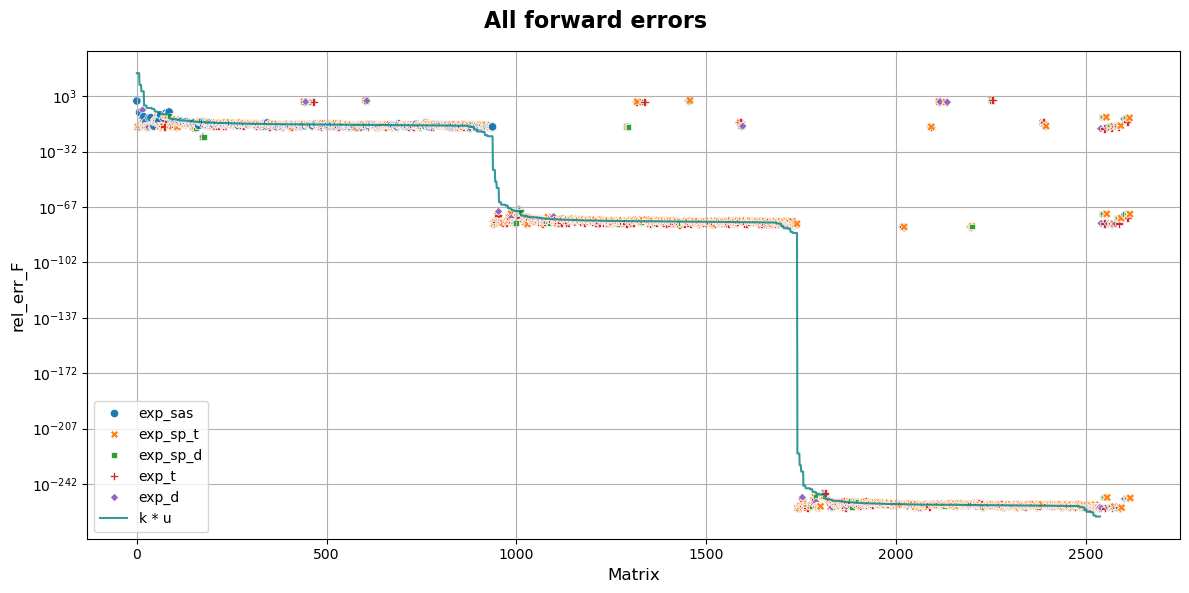

In [85]:
fig, ax = plt.subplots(figsize=(12,6))
fig.suptitle("All forward errors", fontsize=16, fontweight="bold")

produce_plot(df, ax)

plt.tight_layout()
plt.show()

Vediamo i plots separati per precisione

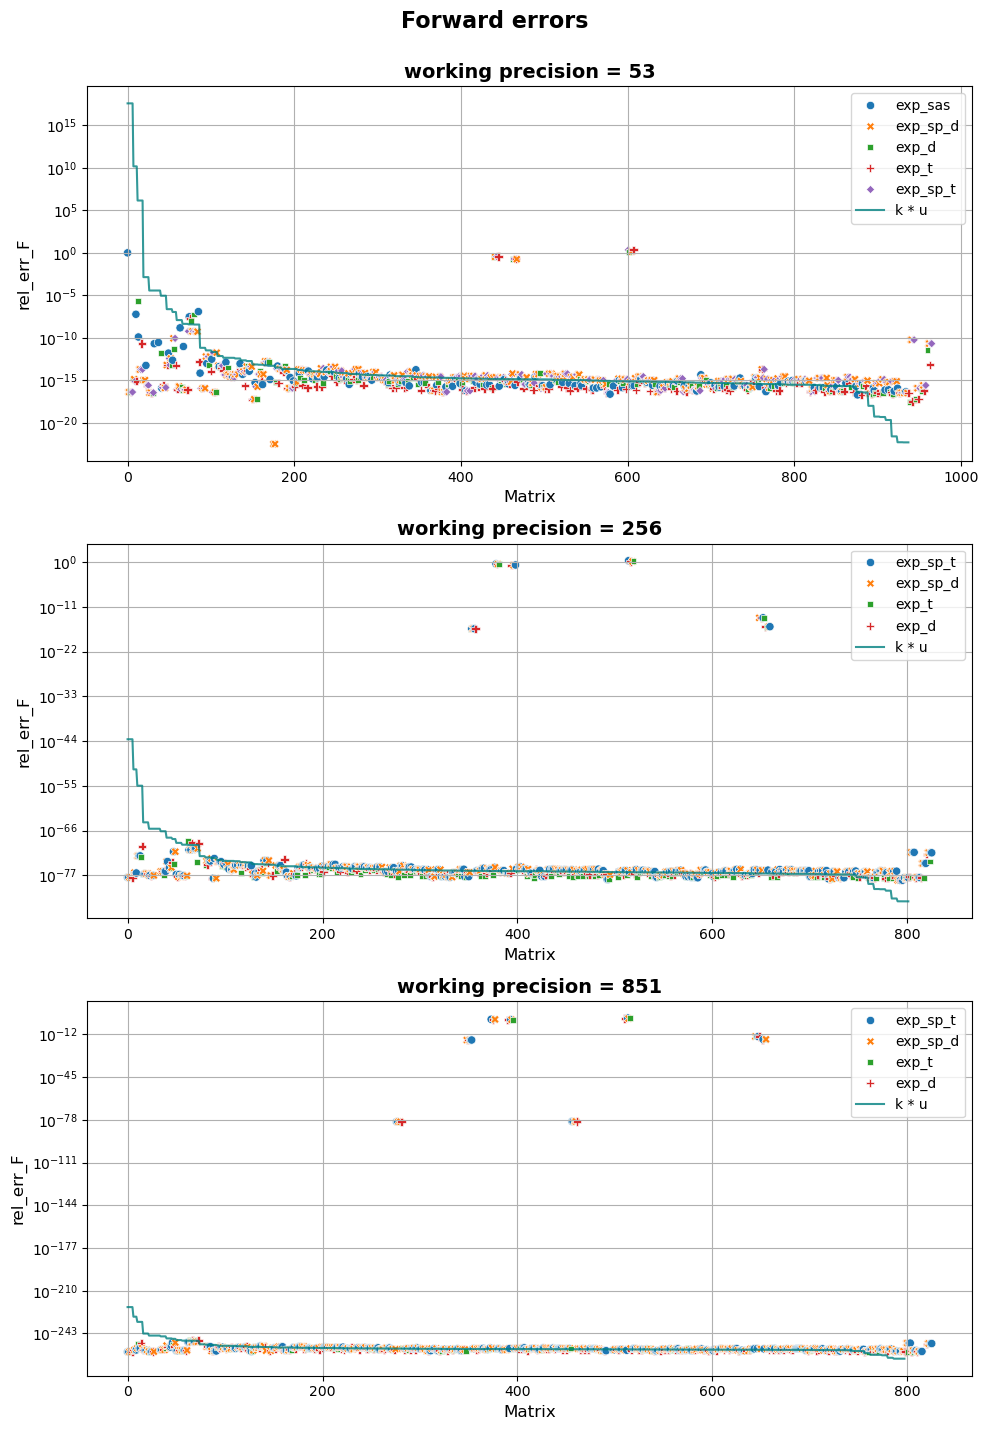

In [31]:
WRK_PRECS = df["precision"].unique()

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
fig.suptitle("Forward errors", fontsize=16, fontweight="bold")

for i, wp in enumerate(WRK_PRECS):
    axs[i].set_title(f"working precision = {wp}", fontsize=14, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    produce_plot(df_inn, axs[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Boh a occhio sembrano grosso modo gli stessi risultati degli autori. Beh, forse la scala andrebbe un pochino ristretta

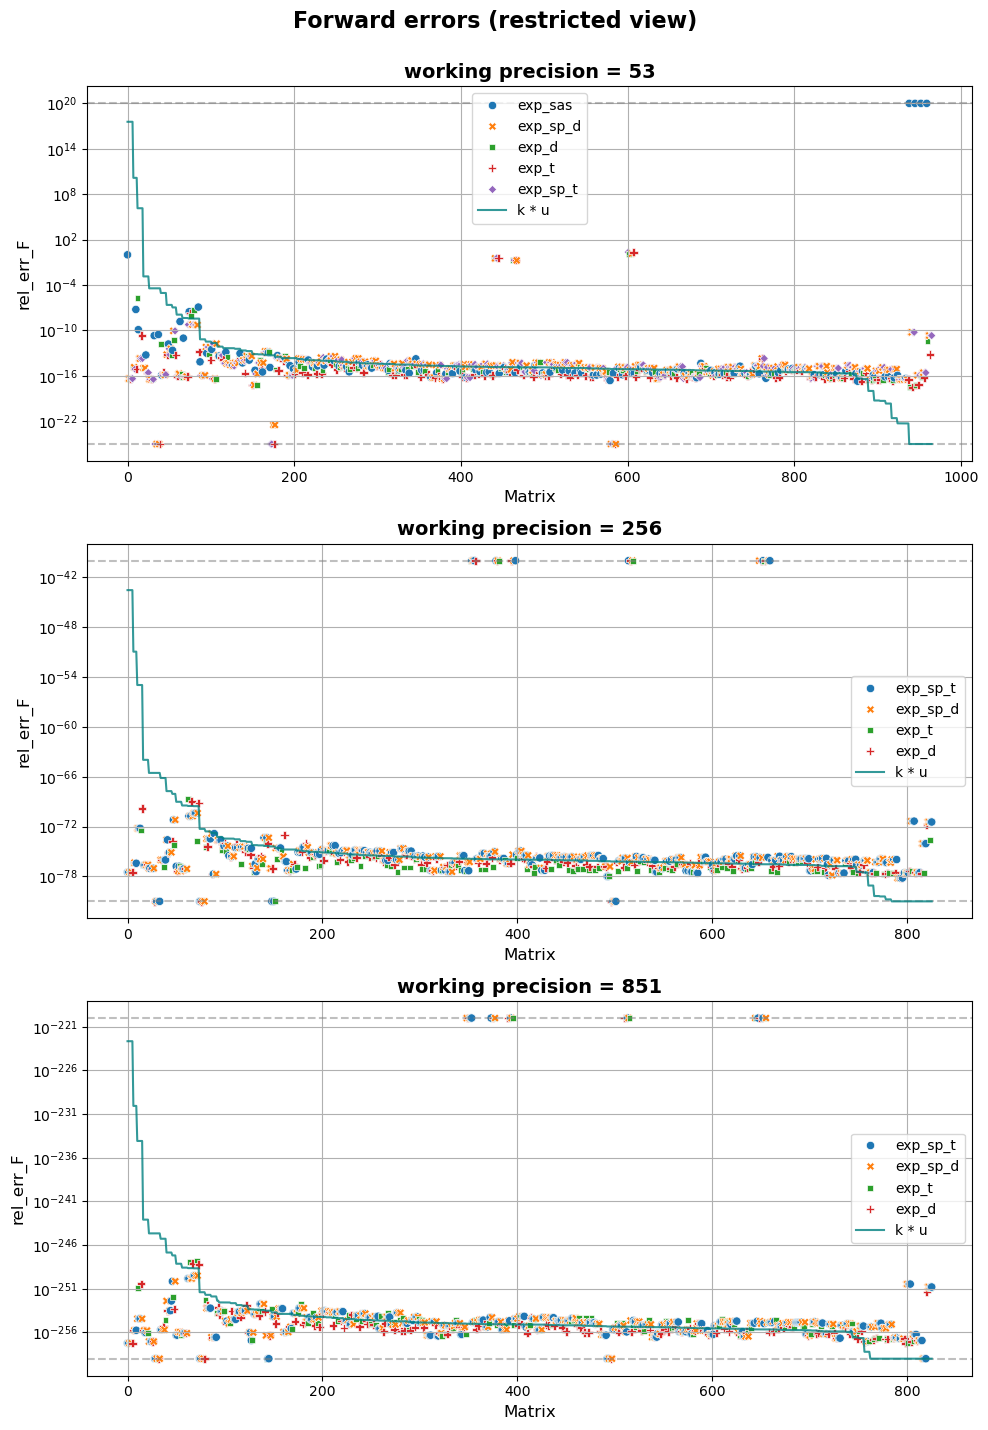

In [36]:
WRK_PRECS = df["precision"].unique()
WINDOWS = [(1e-25, 1e20), (1e-81, 1e-40), (1e-259, 1e-220)]

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
fig.suptitle("Forward errors (restricted view)", fontsize=16, fontweight="bold")

for i, (wp, win) in enumerate(zip(WRK_PRECS, WINDOWS)):
    axs[i].set_title(f"working precision = {wp}", fontsize=14, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    produce_plot(df_inn, axs[i], window=win)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Non sembra male. Alcuni elementi, però, sono veramente fuori scala.

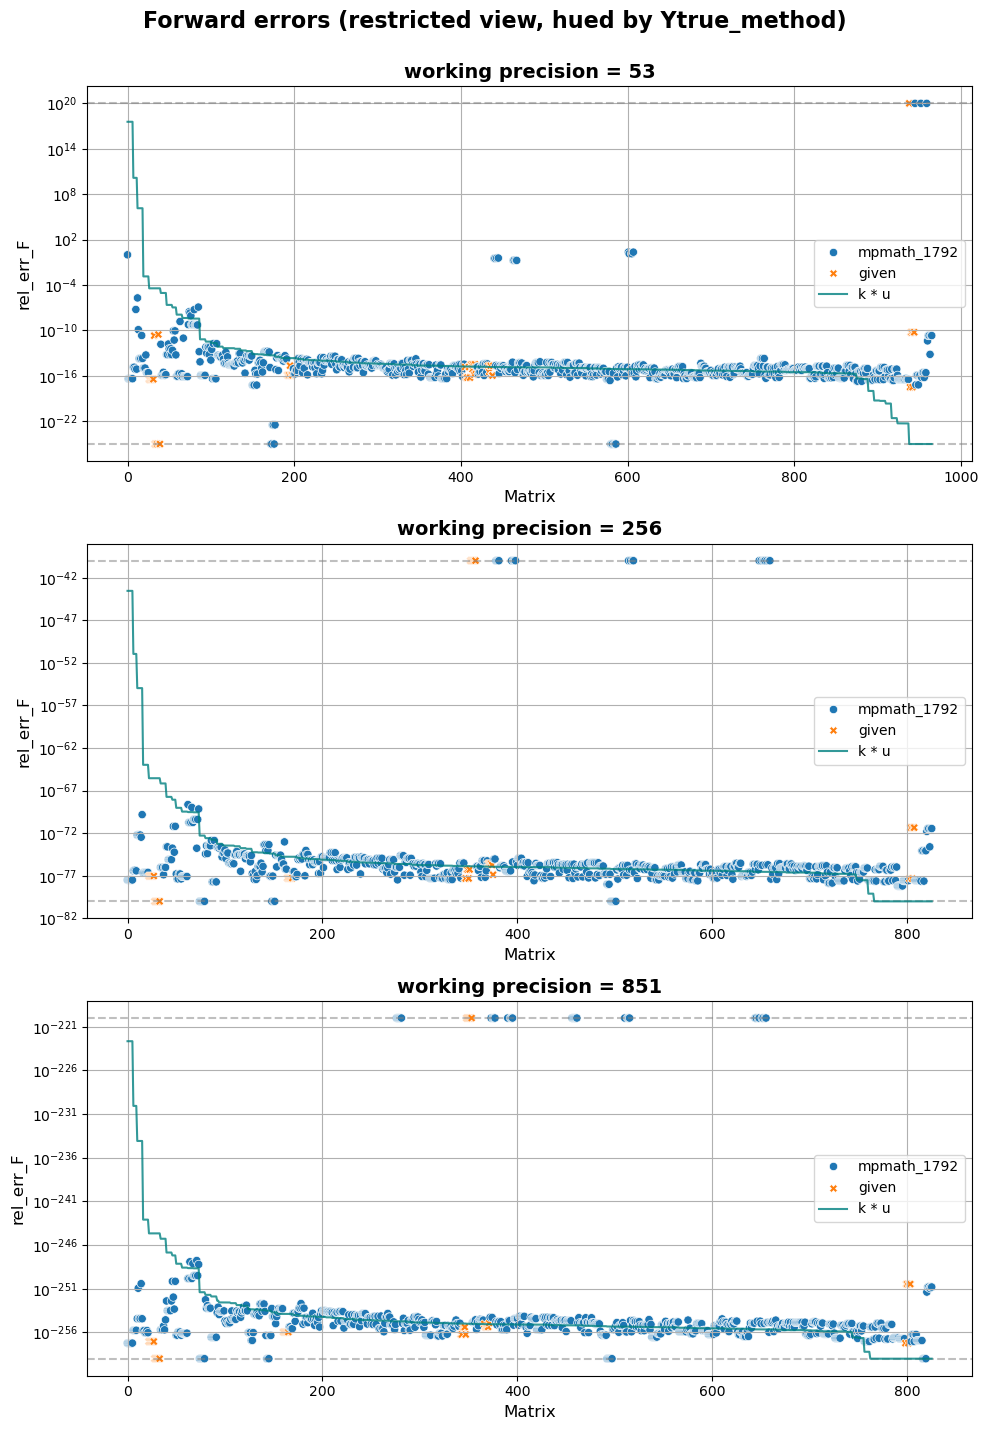

In [32]:
WRK_PRECS = df["precision"].unique()
WINDOWS = [(1e-25, 1e20), (1e-80, 1e-40), (1e-259, 1e-220)]

fig, axs = plt.subplots(len(WRK_PRECS), 1, figsize=(10, 5*len(WRK_PRECS)))
fig.suptitle("Forward errors (restricted view, hued by Ytrue_method)", fontsize=16, fontweight="bold")

for i, (wp, win) in enumerate(zip(WRK_PRECS, WINDOWS)):
    axs[i].set_title(f"working precision = {wp}", fontsize=14, fontweight="bold")
    df_inn = df[df["precision"] == wp]
    produce_plot(df_inn, axs[i], hue="Ytrue_method", window=win)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Vediamo quali sono le matrici per i quali abbiamo valori molto alti dell'errore relativo

**FINIRE DA QUI. INDAGARE**

In [ ]:
for prec in WRK_PRECS:
    df_p = df[df["precision"]==prec]
    print(f"the {df_p.shape[0] - sum(relerr_satisfies_bound_within_factor(df_p, 2))}\
 samples that don't satisfy the n^2 * u * k bound are:")


the 91 samples that don't satisfy the n^2 * u * k bound are:
the 93 samples that don't satisfy the n^2 * u * k bound are:
the 109 samples that don't satisfy the n^2 * u * k bound are:


In [107]:
df[(df["precision"]==851) & (df["abs_err_1"] > Decimal(1e-150))]["kind"].unique()

array(['Fasi_6', 'Fasi_7', 'Fasi_11', 'ward77_test1', 'ward77_test4',
       'dorr_10_100.0', 'hanowa_10', 'dramadah_10_1', 'dramadah_10_3',
       'forsythe_10'], dtype=object)